In [1]:
import numpy as np
import pandas as pd
import sklearn as sks
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# **EDA**

In [3]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

<Axes: xlabel='loan_status', ylabel='count'>

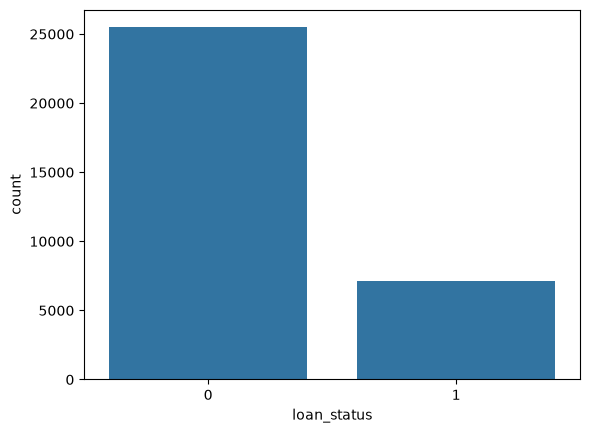

In [4]:
sns.countplot(data = df , x= 'loan_status')

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'PERSONAL'),
  Text(1, 0, 'EDUCATION'),
  Text(2, 0, 'MEDICAL'),
  Text(3, 0, 'VENTURE'),
  Text(4, 0, 'HOMEIMPROVEMENT'),
  Text(5, 0, 'DEBTCONSOLIDATION')])

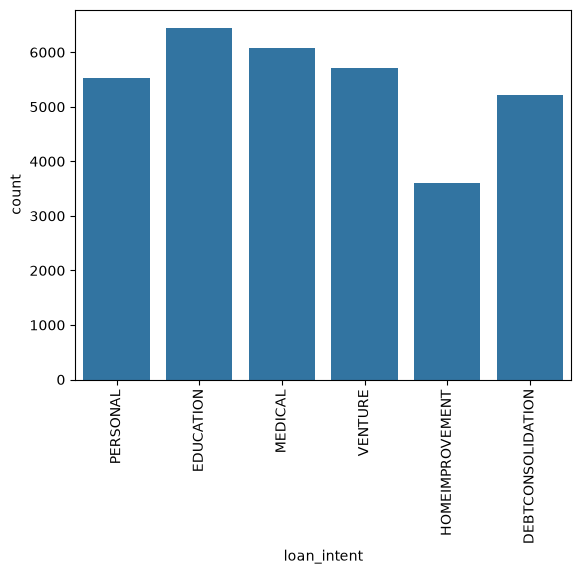

In [5]:
sns.countplot(data = df , x= 'loan_intent')
plt.xticks(rotation=90)

In [6]:
df['loan_intent'].value_counts()

loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

In [7]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [8]:
numerical_cols = df.select_dtypes(include='number')

In [9]:
numerical_cols


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
0,22,59000,123.0,35000,16.02,1,0.59,3
1,21,9600,5.0,1000,11.14,0,0.10,2
2,25,9600,1.0,5500,12.87,1,0.57,3
3,23,65500,4.0,35000,15.23,1,0.53,2
4,24,54400,8.0,35000,14.27,1,0.55,4
...,...,...,...,...,...,...,...,...
32576,57,53000,1.0,5800,13.16,0,0.11,30
32577,54,120000,4.0,17625,7.49,0,0.15,19
32578,65,76000,3.0,35000,10.99,1,0.46,28
32579,56,150000,5.0,15000,11.48,0,0.10,26


person_age


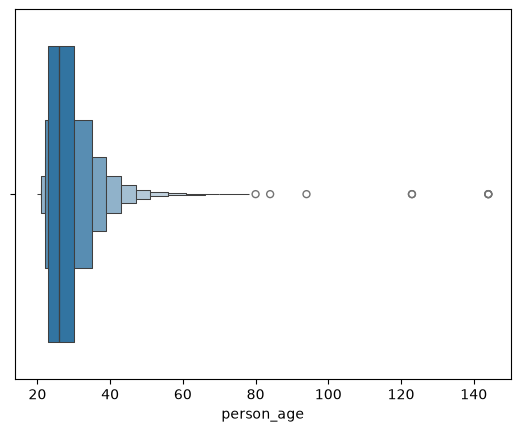

person_income


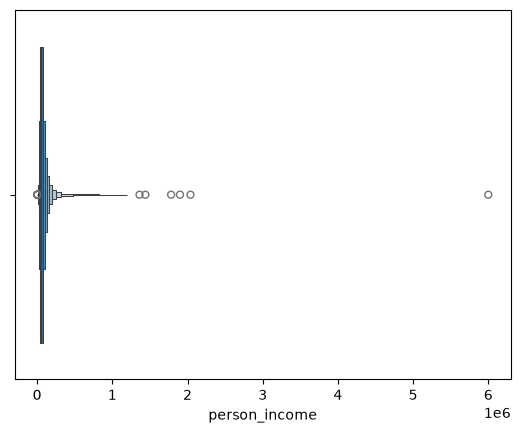

person_emp_length


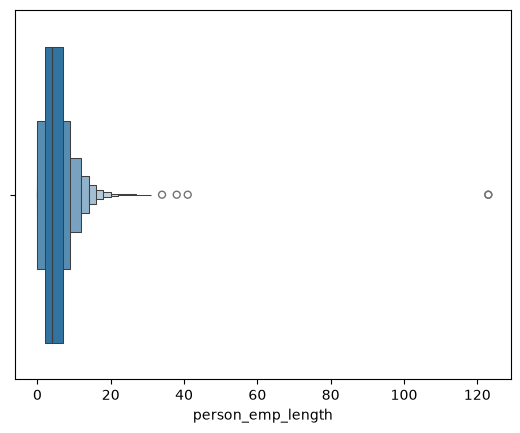

loan_amnt


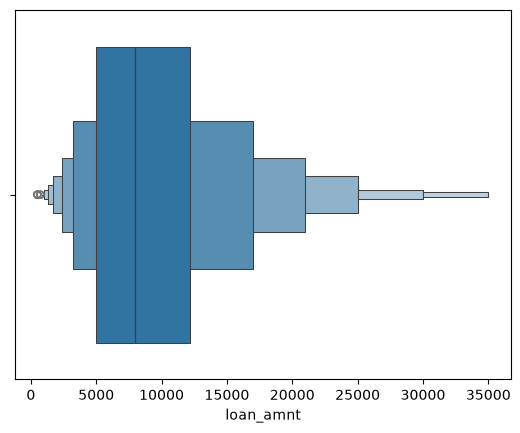

loan_int_rate


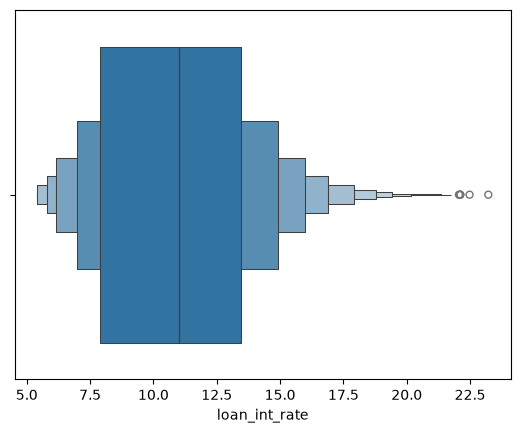

loan_status


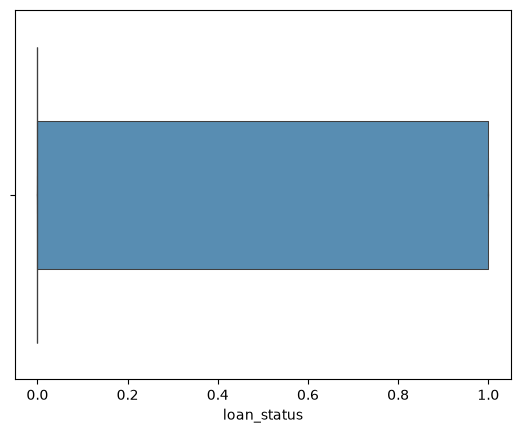

loan_percent_income


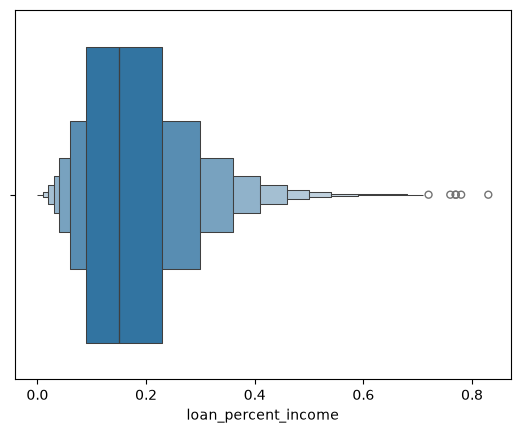

cb_person_cred_hist_length


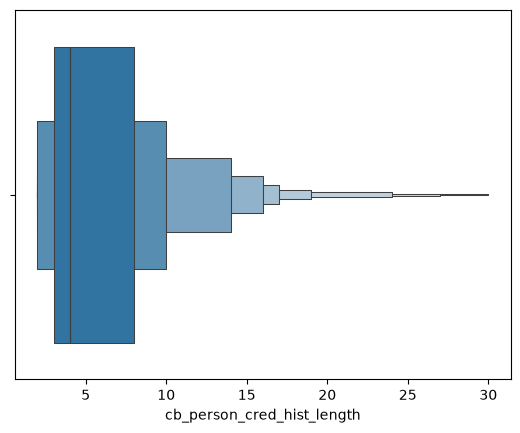

In [10]:
for i in numerical_cols:
    print (i)
    sns.boxenplot(x= df[i])
    plt.show()

In [11]:
(df['person_age']>100).sum()

np.int64(5)

In [12]:
(df['person_emp_length']>100).sum()

np.int64(2)

<Axes: >

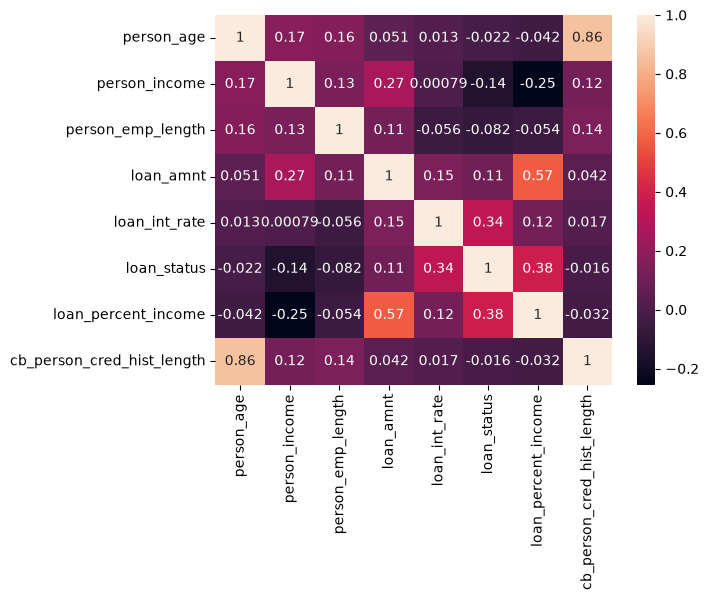

In [13]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [14]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# **Data Validation & Outlire Handling**

In [15]:
df_copy = df.copy()
print(f'Original shape: {df_copy.shape}')

Original shape: (32581, 12)


In [16]:

#remove duplicates row from the dataset
df_copy.drop_duplicates(inplace=True)

print(f'New shape after dropping duplicates: {df_copy.shape}')

New shape after dropping duplicates: (32416, 12)


In [17]:
#remove ages below 18 and above 100
df_copy = df_copy[(df_copy['person_age']>=18) & (df_copy['person_age']<=100)]
print(f'New shape after filtering ages: {df_copy.shape}')

New shape after filtering ages: (32411, 12)


In [18]:
# remove employment length greater the age and extrame outlire (>60)
df_copy = df_copy[df_copy['person_emp_length']<=df_copy['person_age']]
df_copy.shape


(31522, 12)

In [19]:
df_copy = df_copy[df_copy['person_emp_length']<=60]
df_copy.shape

(31522, 12)

In [20]:
#Remove rows negative income and or zero

df_copy = df_copy[df_copy['loan_percent_income']>0]
df_copy.shape

(31514, 12)

In [21]:
df_copy.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,31514.000000,3.151400e+04,31514.000000,31514.000000,28488.000000,31514.000000,31514.000000,31514.000000
mean,27.738941,6.621706e+04,4.782382,9665.264644,11.045573,0.215999,0.169701,5.814368
std,6.213864,4.885095e+04,4.036751,6334.752269,3.230910,0.411520,0.106275,4.061939
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.010000,2.000000
25%,23.000000,3.940500e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.600000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,8.000000e+04,7.000000,12500.000000,13.480000,0.000000,0.230000,8.000000
max,94.000000,1.782000e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [22]:
print("min loan interest :5.42 \nAnd Maximum loan interst :23.22")

min loan interest :5.42 
And Maximum loan interst :23.22


# **Features, Target & Train-Test Split**

In [24]:
X = df_copy.drop('loan_status', axis=1)
y = df_copy['loan_status'] 

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [26]:
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                     'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

# **Handle Class Imbalance**

In [27]:
#0 -> no loan (most)
#1 -> yes loan

neg, pos = np.bincount(y_train)
scale_weigths = neg/pos

In [28]:
scale_weigths

np.float64(3.6292691883951522)

# **Data Preprocessing — Pipelines & Column Transformer**

In [29]:
#Logistic Regression : impute + SCALE Numeric, impute + One-Hot-Encoding
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_lr = ColumnTransformer(
    transformers=[
        #Pipeline - for numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_cols),

        #Pipeline - for Categorical cols.
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy="constant", fill_value="Missing")),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])


## **Preprocessing for XGBoost**

In [30]:
#XGBoost: Impute numeric only (No Scaling), impute + One - Hot Encoding

preprocessor_xg = ColumnTransformer(
    transformers=[
        #Pipeline - for numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), numeric_cols),

        #Pipeline - for Categorical cols.
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy="constant", fill_value="Missing")),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])


# **Evaluation Helper Function**

In [31]:
#We have to evaluate Logistic Model and XGBoost model on the basis of their metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_curve
def evaluate_model(model_name, model, X_test, y_test, threshold=None):
  y_pred_prob = model.predict_proba(X_test)[:,1]

  if threshold:
    y_pred = (y_pred_prob > threshold).astype(int)
  else:
    y_pred = model.predict(X_test)

  #Metrics
  accuracy     = accuracy_score(y_test, y_pred)    #Overall model's preformance
  precision    = precision_score(y_test, y_pred)   #When the model says 1, how oftenly is it actually 1.
  recall       = recall_score(y_test, y_pred)      #of the actual 1 how many did the model catches
  f1           = f1_score(y_test, y_pred)          #Harmonic mean of precision and recall

  conf_matrix   = confusion_matrix(y_test, y_pred)
  class_report  = classification_report(y_test, y_pred)


  print(f"{model_name} Metrics:")
  if threshold is not None: # Only print threshold if provided
    print(f"Used Threshold : {threshold:.2f}")
  print(f"Accuracy : {accuracy:.2f}")
  print(f"Precision : {precision:.2f}")
  print(f"Recall : {recall:.2f}")
  print(f"F1 : {f1:.2f}")
  print()
  print(f"{model_name} Classification Report:")
  print(class_report)


  #Plotting confusion matrix
  sns.heatmap(conf_matrix, annot=True, fmt="d")
  plt.title(f"{model_name} Confusion Matrix")
  plt.ylabel("Actual Values")
  plt.xlabel("Predicted Values")
  plt.show()


  #Plotting ROC-AUC curve
  precisions, recalls, threshold = precision_recall_curve(y_test, y_pred_prob)
  plt.plot(recalls, precisions)
  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.title(f"{model_name} Precision-Recall Curve")
  plt.show()

# **Stratified Cross-Validation**

In [32]:
from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {'roc_auc':'roc_auc', 'accuracy':'accuracy', 'precision':'precision', 'recall':'recall', 'f1':'f1'}

In [33]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
lr_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

In [34]:
import pip
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [35]:
#XGboost Model
from xgboost import XGBClassifier
xgb_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(
        n_estimator=300, max_depth=5, learning_rate=0.1,
        scale_pos_weight=scale_weigths,random_state=42
    ))
])

In [36]:
for cv_name, pipe in [("Logistic Regression", lr_cv_pipeline),
                      ("XGBoost", xgb_cv_pipeline)]:

                      cv_results = cross_validate(pipe, X_train , y_train, cv=cv, scoring=scoring, n_jobs=-1)

                      print(cv_name)
                      print(f"ROC-AUC : {cv_results['test_roc_auc'].mean()}")
                      print(f"Accuracy : {cv_results['test_accuracy'].mean()}")
                      print(f"Precision : {cv_results['test_precision'].mean()}")
                      print(f"Recall : {cv_results['test_recall'].mean()}")
                      print(f"F1 : {cv_results['test_f1'].mean()}")
                      print()

Logistic Regression
ROC-AUC : 0.8704112370572847
Accuracy : 0.8107970383696639
Precision : 0.5434536939288777
Recall : 0.7770851130150546
F1 : 0.6395907250394709

XGBoost
ROC-AUC : 0.9395034977171178
Accuracy : 0.9097617923383693
Precision : 0.7934877055912609
Recall : 0.7871852806631788
F1 : 0.7903071039256061



# **Baseline Model — Logistic Regression**

In [37]:
from sklearn.pipeline import Pipeline
baseline_model = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(class_weight= "balanced"))
])
baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['person_age','person_income','person_home_ownership',..., 'loan_percent_income','cb_person_default_on_file', 'cb_person_cred_hist_length']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped

Baseline Logistic Model Metrics:
Accuracy : 0.82
Precision : 0.55
Recall : 0.80
F1 : 0.65

Baseline Logistic Model Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.82      0.88      4942
           1       0.55      0.80      0.65      1361

    accuracy                           0.82      6303
   macro avg       0.75      0.81      0.76      6303
weighted avg       0.85      0.82      0.83      6303



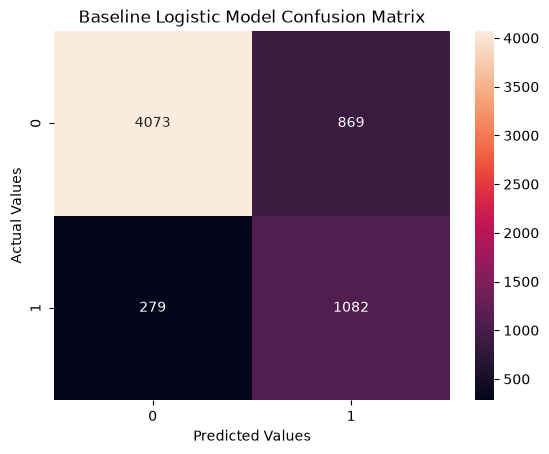

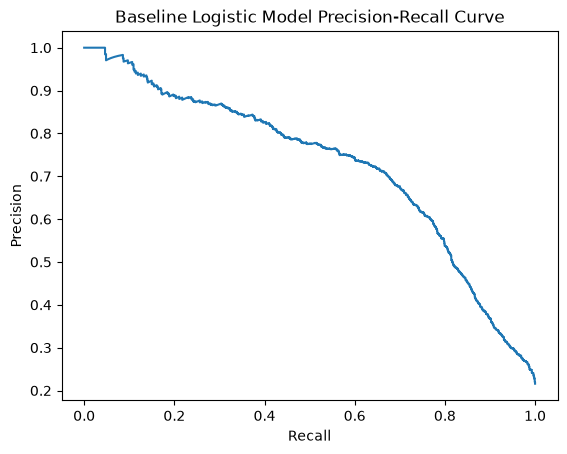

In [38]:
evaluate_model("Baseline Logistic Model", baseline_model ,X_test, y_test)

# **XGBoost Hyperparameter Tuning**

In [39]:
xg_model = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(learning_rate=0.1,
        scale_pos_weight=scale_weigths,random_state=42))
])
xg_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['person_age','person_income','person_home_ownership',..., 'loan_percent_income','cb_person_default_on_file', 'cb_person_cred_hist_length']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped

In [40]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_grid = {
    "classifier__n_estimators": randint(150, 600),
    "classifier__max_depth" : randint(3,9),
    "classifier__learning_rate" : uniform(0.01, 0.5),
    "classifier__subsample": uniform(0.6,0.4), #Rows sampling
    "classifier__colsample_bytree" :uniform(0.6,0.4), #column sampling
    "classifier__min_child_weight": randint(1, 10),
    "classifier__gamma": uniform(0 , 5)
}
# lower gamma -> more splits -> complex tree -> higher overfitting risk
# higher gamma -> less splits ->  simpler tree -> low overfitting

In [41]:
random_search = RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=150,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': <scipy.stats....002A02DE62C10>, 'classifier__gamma': <scipy.stats....002A02D6FF820>, 'classifier__learning_rate': <scipy.stats....002A02DE6AF90>, 'classifier__max_depth': <scipy.stats....002A02D583390>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",150
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index

In [42]:
print(f"Score after performing Tunning {random_search.best_score_:.2f}")

Score after performing Tunning 0.90


In [43]:
random_search.best_params_

{'classifier__colsample_bytree': np.float64(0.808780946623768),
 'classifier__gamma': np.float64(1.7523940548178274),
 'classifier__learning_rate': np.float64(0.036106775809808526),
 'classifier__max_depth': 7,
 'classifier__min_child_weight': 7,
 'classifier__n_estimators': 590,
 'classifier__subsample': np.float64(0.8916577347393493)}

# **Compare Both Models Side by Side**

Logistic Regression Metrics:
Accuracy : 0.82
Precision : 0.55
Recall : 0.80
F1 : 0.65

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.82      0.88      4942
           1       0.55      0.80      0.65      1361

    accuracy                           0.82      6303
   macro avg       0.75      0.81      0.76      6303
weighted avg       0.85      0.82      0.83      6303



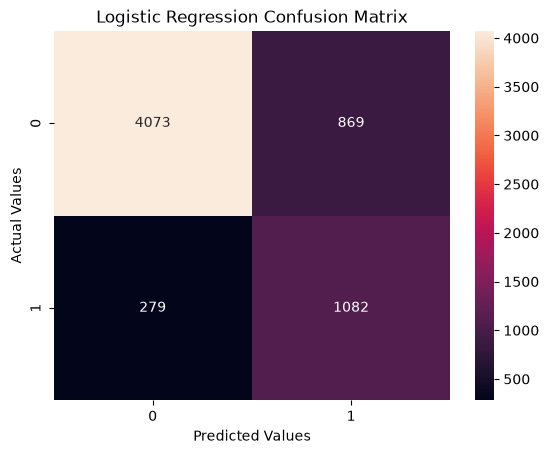

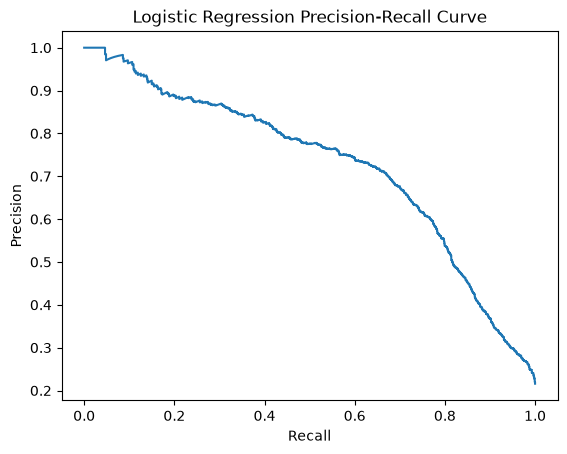

In [44]:
evaluate_model("Logistic Regression", baseline_model, X_test, y_test)

XGBoost Metrics:
Accuracy : 0.92
Precision : 0.83
Recall : 0.80
F1 : 0.82

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      4942
           1       0.83      0.80      0.82      1361

    accuracy                           0.92      6303
   macro avg       0.89      0.88      0.88      6303
weighted avg       0.92      0.92      0.92      6303



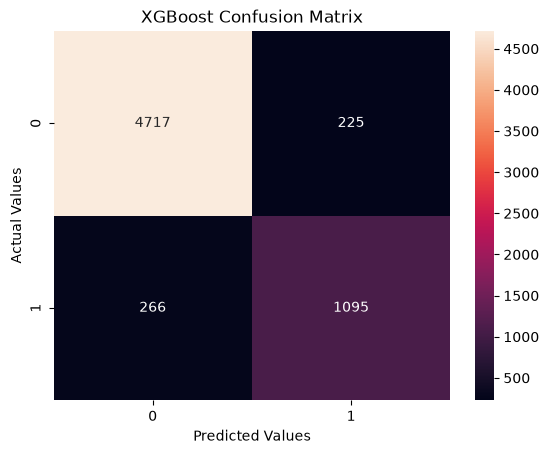

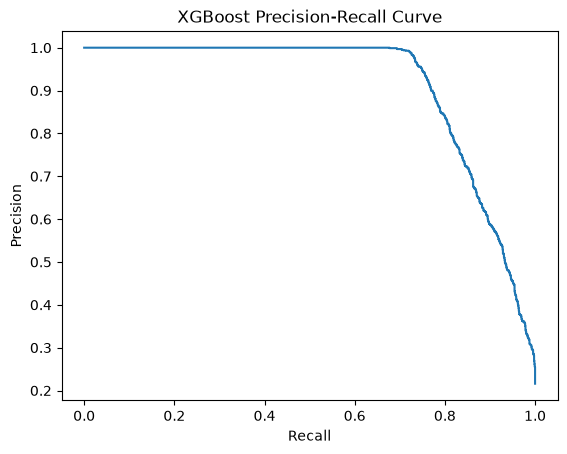

In [45]:
#Passing the XGBoost model after performing Hyperparameter Tuning
evaluate_model("XGBoost", random_search, X_test, y_test)